# **Project 01**

## **Bài toán số 1**

**Cài đặt**

**Import thư viện**

In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
from seaborn._core.typing import default
import matplotlib.pyplot as plt
import re, os, math, unicodedata
from scipy import stats
from scipy.special import inv_boxcox
from scipy.stats import skew
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import builtins
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score




**Load dữ liệu lưu vào biến data frame**

In [88]:

# Load dữ liệu (tương đương spark.read.csv)
folder_path = 'Data'
csv_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv')]
data = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# Loại bỏ trùng lặp
data = data.drop_duplicates()

In [89]:
print(data[['gia_ban', 'dien_tich_dat']].head(5))

   gia_ban dien_tich_dat
0  3,85 tỷ         36 m²
1  9,79 tỷ         62 m²
2   7,2 tỷ         54 m²
3   8,5 tỷ         83 m²
4  2,85 tỷ         18 m²


**Xem thông tin chung dữ liệu**

In [90]:
# Print the shape of the dataset (rows, columns)
print("\nDataset shape:")
data.shape

# Display data types and non-null counts for each column
print("\nData types and missing values:")
data.info()

# Show summary statistics for each column (e.g., mean, std, min, max)
print("\nDescriptive statistics:")
data.describe(include='all')

# Check for missing values
print("\nMissing values per column:")
data.isnull().sum()


Dataset shape:

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
Index: 7941 entries, 0 to 8272
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tieu_de              7940 non-null   object 
 1   gia_ban              7939 non-null   object 
 2   don_gia              7939 non-null   object 
 3   dien_tich            7939 non-null   object 
 4   dia_chi              7941 non-null   object 
 5   mo_ta                7939 non-null   object 
 6   dien_thoai           3944 non-null   object 
 7   loai_hinh            7939 non-null   object 
 8   dien_tich_dat        7939 non-null   object 
 9   dien_tich_su_dung    3746 non-null   object 
 10  gia_m2               7939 non-null   object 
 11  giay_to_phap_ly      7440 non-null   object 
 12  so_phong_ngu         7939 non-null   object 
 13  so_phong_ve_sinh     5963 non-null   object 
 14  tong_so_tang         5488 non-null   float64


tieu_de                   1
gia_ban                   2
don_gia                   2
dien_tich                 2
dia_chi                   0
mo_ta                     2
dien_thoai             3997
loai_hinh                 2
dien_tich_dat             2
dien_tich_su_dung      4195
gia_m2                    2
giay_to_phap_ly         501
so_phong_ngu              2
so_phong_ve_sinh       1978
tong_so_tang           2453
tinh_trang_noi_that    3519
huong_cua_chinh        6623
dac_diem               2746
chieu_ngang            1851
chieu_dai              1987
ma_can                 7916
ten_phan_khu_lo        7916
bieu_do_gia               0
dtype: int64

**Xem thông tin mẫu**

In [91]:
# Display the first 5 rows to understand the structure of the data
print("First rows:")
data.head(1)


First rows:


,tieu_de,gia_ban,don_gia,dien_tich,dia_chi,mo_ta,dien_thoai,loai_hinh,dien_tich_dat,dien_tich_su_dung,...,so_phong_ve_sinh,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,ma_can,ten_phan_khu_lo,bieu_do_gia
0,🍀VÂN KIỀU AN CƯ🍀 40m2 - Hẻm Ô Tô - Gần mặt tiề...,"3,85 tỷ","106,94 triệu/m²",36 m²,"Đường Lê Quang Định, Phường 7, Quận Bình Thạnh...",🍀VÂN KIỀU AN CƯ🍀\n\n🏡 Nhà Lê Quang Định P5 – G...,NaN,"Nhà ngõ, hẻm",36 m²,NaN,...,2 phòng,2.0,Nội thất đầy đủ,NaN,Nhà nở hậu,4.5 m,8 m,NaN,NaN,"[134.04, 125.8, 125.8, 125.8, 138.64, 138.64, ..."


**Xử lý dữ liệu trùng --> đối với dữ liệu đã cho là các dòng không có dữ liệu trong quá trình crawl data**

In [92]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df = pd.DataFrame({'Số NaN': missing, 'Tỷ lệ (%)': missing_pct})
missing_df = missing_df[missing_df['Số NaN'] > 0].sort_values('Tỷ lệ (%)', ascending=False)
print('Các cột có giá trị thiếu:')
missing_df

Các cột có giá trị thiếu:


,Số NaN,Tỷ lệ (%)
ten_phan_khu_lo,7916,99.69
ma_can,7916,99.69
huong_cua_chinh,6623,83.40
dien_tich_su_dung,4195,52.83
dien_thoai,3997,50.33
tinh_trang_noi_that,3519,44.31
dac_diem,2746,34.58
tong_so_tang,2453,30.89
chieu_dai,1987,25.02
so_phong_ve_sinh,1978,24.91


In [93]:
print(f"Số dòng còn lại: {len(data)}")

Số dòng còn lại: 7941


**Tiền xử lý dữ liệu (Data Cleaning)**

**Xử lý đơn vị tiền tệ**

Thay các hàm udf và regexp_replace của Spark sang các hàm xử lý chuỗi của Pandas

In [94]:
def standardize_price(price_str):
    if pd.isna(price_str): return None
    price_str = str(price_str).lower().replace(',', '.')
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", price_str)
    if not nums: return None
    val = float(nums[0])
    if 'tỷ' in price_str: return val
    if 'triệu' in price_str: return val / 1000
    return val

# Áp dụng chuẩn hóa giá và diện tích
data['gia_ban'] = data['gia_ban'].apply(standardize_price)

cols_to_convert = ['dien_tich', 'dien_tich_dat', 'so_phong_ngu', 'chieu_ngang', 'tong_so_tang']
for col in cols_to_convert:
    data[col] = data[col].astype(str).str.replace('[^0-9,.]', '', regex=True).str.replace(',', '.')
    data[col] = pd.to_numeric(data[col], errors='coerce')


In [95]:
print(data[['gia_ban', 'dien_tich_dat']].head(5))

   gia_ban  dien_tich_dat
0     3.85           36.0
1     9.79           62.0
2     7.20           54.0
3     8.50           83.0
4     2.85           18.0


**Chuyển đổi các cột có đơn vị tính về dạng chỉ có số để tính toán**\
Riêng 2 cột 'don_gia', 'gia_m2' chỉ xử lý tượng trưng vì sẽ drop vì lý do ở những bước dưới

In [96]:
columns_to_convert = [
    'gia_ban', 'don_gia', 'dien_tich', 'dien_tich_dat', 'dien_tich_su_dung', 'gia_m2', 'so_phong_ngu',
    'so_phong_ve_sinh', 'chieu_ngang', 'chieu_dai'
]

for col_name in columns_to_convert:
    # 1. Chuyển sang chuỗi, loại bỏ các ký tự không phải số, dấu phẩy, dấu chấm
    # 2. Thay dấu phẩy thành dấu chấm
    # 3. Chuyển sang kiểu số (float), các giá trị không hợp lệ sẽ tự động thành NaN (tương đương null)
    data[col_name] = (
        data[col_name]
        .astype(str)
        .str.replace(r'[^0-9,.]', '', regex=True)
        .str.replace(',', '.')
    )

    # Sử dụng pd.to_numeric với errors='coerce' để chuyển chuỗi rỗng hoặc lỗi thành NaN
    data[col_name] = pd.to_numeric(data[col_name], errors='coerce')

# Hiển thị 3 dòng đầu
data[columns_to_convert].head(3)

,gia_ban,don_gia,dien_tich,dien_tich_dat,dien_tich_su_dung,gia_m2,so_phong_ngu,so_phong_ve_sinh,chieu_ngang,chieu_dai
0,3.85,106.94,36.0,36.0,NaN,106.94,2.0,2.0,4.5,8.0
1,9.79,157.90,62.0,62.0,NaN,157.90,4.0,NaN,NaN,NaN
2,7.20,133.33,54.0,54.0,NaN,133.33,3.0,2.0,7.0,7.7


**Kiểm tra và điền các dòng giá trị không hợp lệ của chiều ngang về null**

In [97]:
def clean_invalid_dimensions_pandas(df):
    # Tạo biến tạm để tính toán
    df['dien_tich_tmp'] = np.where(
        df['chieu_ngang'].notna() & df['chieu_dai'].notna(), # Điều kiện (When)
        df['chieu_ngang'] * df['chieu_dai'],                 # Kết quả nếu True
        0                                                    # Kết quả nếu False
    )

    # Điều kiện 1: chieu_ngang > dien_tich
    cond1 = df['chieu_ngang'] > df['dien_tich']

    # Điều kiện 2: sai lệch diện tích > 0 (chỉ kiểm tra khi cả 3 cột not null)
    cond2 = (df['chieu_ngang'].notna()) & \
            (df['chieu_dai'].notna()) & \
            (df['dien_tich'].notna()) & \
            (abs(df['dien_tich'] - df['dien_tich_tmp']) > 0)

    # Nếu vi phạm bất kỳ điều kiện nào (cond1 HOẶC cond2) -> Gán NaN
    df['chieu_ngang'] = np.where(cond1 | cond2, np.nan, df['chieu_ngang'])

    # Loại bỏ cột tạm dien_tich_tmp để làm sạch DataFrame kết quả
    df = df.drop(columns=['dien_tich_tmp'])
    return df

# Sử dụng:
data = clean_invalid_dimensions_pandas(data)

In [98]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7941 entries, 0 to 8272
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tieu_de              7940 non-null   object 
 1   gia_ban              7939 non-null   float64
 2   don_gia              7939 non-null   float64
 3   dien_tich            7939 non-null   float64
 4   dia_chi              7941 non-null   object 
 5   mo_ta                7939 non-null   object 
 6   dien_thoai           3944 non-null   object 
 7   loai_hinh            7939 non-null   object 
 8   dien_tich_dat        7939 non-null   float64
 9   dien_tich_su_dung    3746 non-null   float64
 10  gia_m2               7939 non-null   float64
 11  giay_to_phap_ly      7440 non-null   object 
 12  so_phong_ngu         7939 non-null   float64
 13  so_phong_ve_sinh     5963 non-null   float64
 14  tong_so_tang         5488 non-null   float64
 15  tinh_trang_noi_that  4422 non-null   object

**Kiểm tra biến numerical mang giá trị 0 hoặc nhỏ hơn 0 là các giá trị invalid**

In [99]:
# Lọc các cột có kiểu dữ liệu là số (tương đương double, integer trong Spark)
numeric_df = data.select_dtypes(include=['number'])

# Đếm các giá trị bằng 0 trong các cột này
zero_and_negative_count = (numeric_df <= 0).sum()

# Hiển thị kết quả
zero_and_negative_count.to_frame(name='zero_and_negative_count').T

,gia_ban,don_gia,dien_tich,dien_tich_dat,dien_tich_su_dung,gia_m2,so_phong_ngu,so_phong_ve_sinh,tong_so_tang,chieu_ngang,chieu_dai
zero_and_negative_count,0,0,0,0,0,0,0,0,0,0,0


**Kiểm tra null**

In [100]:
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()

print("Số lượng giá trị Null trong các cột số:")
data[numeric_cols].isnull().sum()

Số lượng giá trị Null trong các cột số:


gia_ban                 2
don_gia                 2
dien_tich               2
dien_tich_dat           2
dien_tich_su_dung    4195
gia_m2                  2
so_phong_ngu            2
so_phong_ve_sinh     1978
tong_so_tang         2453
chieu_ngang          5573
chieu_dai            1987
dtype: int64

**Vẽ biểu đồ tương quan để xét tính đa cộng tuyến**\
Nhận xét:
- 'chieu_dai' có tương quan mạnh với 'dien_tich_dat' (0.76) -> cần drop cột 'chieu_dai' để tránh đa cộng tuyến
- Tương tự cần drop cột 'so_phong_ve_sinh', giữ lại 'so_phong_ngu', vì 'so_phong_ngu' không có Null

In [101]:
def visualize_correlation(df):
    #
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    corr_df = df[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of Numeric Features')
    plt.show()

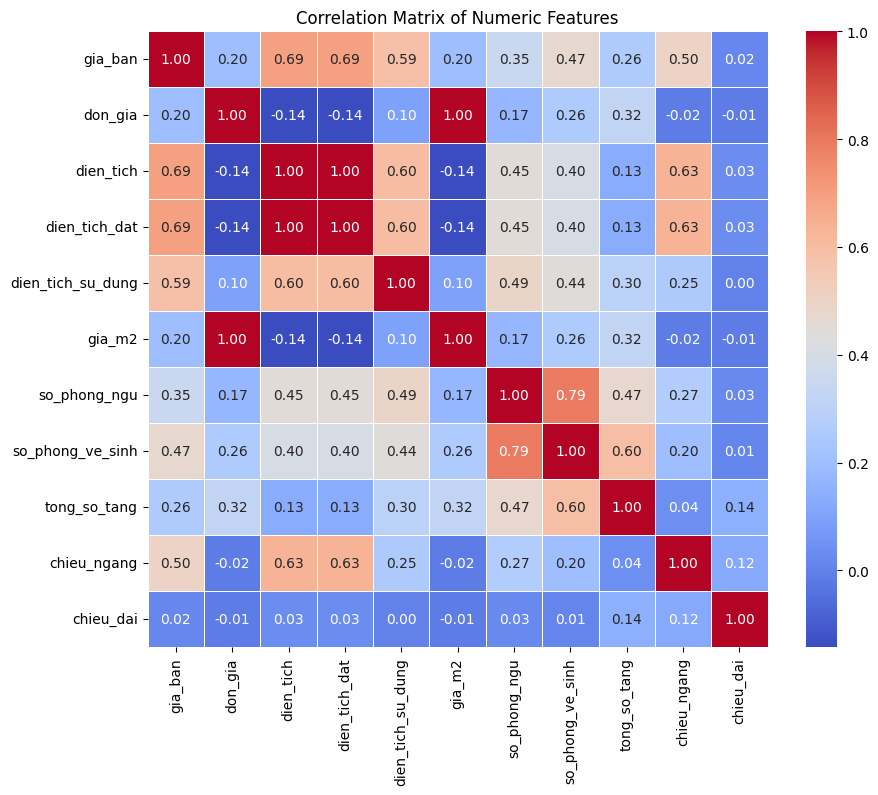

In [102]:
visualize_correlation(data)

**Drop các cột không có ý nghĩa thống kê và có sự tương quan, một số cột khác sẽ được drop sau khi trích xuất thông tin, vd: 'tieu_de', 'mo_ta', 'dia_chi', 'chieu_dai'**
- Đơn giá = giá bán/ diện tích đất
- Diện tích = diện tích đất
- Chiều dài: tương quan với Diện tích đất
- Số phòng vệ sinh tương quan với Số phòng ngủ
- Giá m2 = đơn giá
- Điện thoại, mã căn, tên phân khu/lô, biểu đồ giá: không có ý nghĩa thống kê

In [103]:
# Danh sách các cột cần loại bỏ
cols_to_drop = ['don_gia', 'dien_tich', 'so_phong_ve_sinh', 'gia_m2', 'dien_thoai', 'ma_can', 'ten_phan_khu_lo', 'bieu_do_gia']

# Sử dụng drop với axis=1 để xóa cột
# errors='ignore' giúp code không bị lỗi nếu một trong các cột đã bị xóa trước đó
data = data.drop(columns=cols_to_drop, errors='ignore')

# Hiển thị 3 dòng đầu (tương đương .show(3))
data.head(3)

,tieu_de,gia_ban,dia_chi,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai
0,🍀VÂN KIỀU AN CƯ🍀 40m2 - Hẻm Ô Tô - Gần mặt tiề...,3.85,"Đường Lê Quang Định, Phường 7, Quận Bình Thạnh...",🍀VÂN KIỀU AN CƯ🍀\n\n🏡 Nhà Lê Quang Định P5 – G...,"Nhà ngõ, hẻm",36.0,NaN,Đã có sổ,2.0,2.0,Nội thất đầy đủ,NaN,Nhà nở hậu,4.5,8.0
1,"9.xty,Nhà Hẻm Xe Hơi,Xây Mới Khu VIP giáp Phạm...",9.79,"Đường Phạm Văn Đồng, Phường 13, Quận Bình Thạn...","CHỈ 9.XTY - NHÀ MỚI KENG,XE HƠI NGỦ NHÀ GIÁP B...","Nhà ngõ, hẻm",62.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN
2,XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,7.20,"Đường Nơ Trang Long, Phường 13, Quận Bình Thạn...",XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,"Nhà ngõ, hẻm",54.0,NaN,Đã có sổ,3.0,2.0,Hoàn thiện cơ bản,NaN,Hẻm xe hơi,NaN,7.7


**Thêm feature là 2 cột địa chỉ cũ, địa chỉ mới từ cột địa chỉ, vì địa chỉ phản ánh khu vực mặt bằng giá nên có liên quan đến giá nhà, vd nhà quận 1 thường đắt hơn nhà các quận khác, sau đó drop cột địa chi vì không còn nhu cầu phân tích thống kê**

In [104]:
# 1. Trích xuất chỉ lấy QUẬN (Bỏ qua Phường để Model tập trung hơn)
# Regex này sẽ tìm chữ "Quận..." hoặc "Huyện..." trong địa chỉ
data['quan_huyen'] = data['dia_chi'].str.extract(r'(Quận\s+[^,]+|Huyện\s+[^,]+)', expand=False)

# 2. Xử lý trường hợp không tìm thấy (NaN)
data['quan_huyen'] = data['quan_huyen'].replace(['', np.nan], 'Chưa xác định')

# 3. Loại bỏ cột dia_chi gốc
data = data.drop(columns=['dia_chi'])

# Kiểm tra thử xem danh sách Quận đã gọn chưa
print("Các quận hiện có:", data['quan_huyen'].unique())
data[['quan_huyen']].head(3)

Các quận hiện có: ['Quận Bình Thạnh' 'Chưa xác định' 'Quận Gò Vấp' 'Quận Phú Nhuận']


,quan_huyen
0,Quận Bình Thạnh
1,Quận Bình Thạnh
2,Quận Bình Thạnh


**Xử lý Null**

**Chúng ta sẽ xử lý theo thứ tự lần lượt như sau:**
- 'loai_hinh', 'dien_tich_dat', 'so_phong_ngu': xử lý null bằng cách xóa 2 dòng dữ liệu invalid
- 'tong_so_tang': được trích xuất thông tin từ 2 cột 'tieu_de' và 'mo_ta'
- 'dien_tich_su_dung' có mối tương quan với 'dien_tich_dat' và 'tong_so_tang', nên dùng model Linear Regression để dự đoán
- 'chieu_ngang' được xử lý lần lượt qua 2 phương án:\
\+ PA1: Tính dựa vào 'dien_tich_dat' và 'chieu_dai' sẵn có: chieu_ngang = dien_tich_dat/chieu_dai\
\+ PA2: Tính dựa vào median / mean tỷ lệ thực tế trong dữ liệu
→ Tính ratio = chieu_ngang / chieu_dai (hoặc ngược lại) từ các hàng có cả 2 cột không null → lấy median(ratio) → chieu_ngang ≈ sqrt(dien_tich_dat / median_ratio)
- 'giay_to_phap_ly', 'tinh_trang_noi_that', 'dac_diem': tỉ lệ null thấp --> xử lý null bằng cách điền giá trị 'Chưa xác định', 'Hiện trạng khác'
- 'huong_cua_chinh': tỉ lệ null cao, nhưng do yếu tố ngẫu nhiên của hướng --> dùng phương pháp random

**Kiểm tra và xử lý 2 dòng dữ liệu invalid, 2 dòng này làm tăng số dòng null của tất cả các cột**

In [105]:
# 1. Lọc các dòng có 'dien_tich_dat' là Null
null_data = data[data['dien_tich_dat'].isna()]

# 2. In kết quả dạng bảng
if null_data.empty:
    print("Không có dòng nào bị Null trong cột dien_tich_dat.")
else:
    print(f"Tìm thấy {len(null_data)} dòng bị Null:")
    display(null_data.head(10))

Tìm thấy 2 dòng bị Null:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,quan_huyen
1385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chưa xác định
1814,Bad gateway Error code 502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chưa xác định


In [106]:
# Xóa null các dòng invalid
data = data.dropna(subset=['dien_tich_dat'])
null_counts_df = data.isnull().sum().to_frame(name='null_counts').T
print("Bảng thống kê số lượng Null sau khi xóa dòng invalid:")
display(null_counts_df)

Bảng thống kê số lượng Null sau khi xóa dòng invalid:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,quan_huyen
null_counts,0,0,0,0,0,4193,499,0,2451,3517,6621,2744,5571,1985,0


**Xử lý null cho cột 'tong_so_tang', phương án như sau:**
- Dùng regex để nhận diện số lầu, lửng hoặc tầng
- Ưu tiên nếu có thông tin số tầng thì lấy số tầng trực tiếp từ text
- Tìm thông tin lầu, lửng để suy ra số tầng = lầu + lửng + 1
- Nếu không có thông tin lầu, lửng hoặc số tầng thì mặc định số tầng = 1

In [107]:
# --- Giữ nguyên hàm logic (vì đây là Python thuần) ---
def extract_floor_count(text):
    if not text or not isinstance(text, str):
        return None

    text_lower = text.lower()

    lau_variants = ['lầu', 'lẩu', 'làu', 'lâù', 'lâu']
    lung_variants = ['lửng', 'lững', 'lừng', 'lữn', 'lưng', 'lủng']

    lau_pattern = '|'.join(lau_variants)
    lung_pattern = '|'.join(lung_variants)

    tang_pattern = r'(\d+)\s*tầng'
    tang_matches = re.findall(tang_pattern, text_lower)

    if tang_matches:
        return int(tang_matches[0])

    floor_pattern = fr'(\d+)\s*({lau_pattern})'
    mezz_pattern = fr'(\d+)\s*({lung_pattern})'

    floor_matches = re.findall(floor_pattern, text_lower)
    mezz_matches = re.findall(mezz_pattern, text_lower)

    floor_numbers = set([match[0] for match in floor_matches])
    mezz_numbers = set([match[0] for match in mezz_matches])

    has_lau = any(variant in text_lower for variant in lau_variants)
    has_lung = any(variant in text_lower for variant in lung_variants)

    if floor_numbers or mezz_numbers or has_lau or has_lung:
        total_floors = 1
        for f in floor_numbers:
            total_floors += int(f)
        for m in mezz_numbers:
            total_floors += int(m)

        if has_lau and not floor_numbers:
            total_floors += 1
        if has_lung and not mezz_numbers:
            total_floors += 1

        return total_floors
    return None

# --- 1. Tạo hai cột mới bằng .apply() ---
# Pandas xử lý tương đương với withColumn + UDF
data['mo_ta_so_tang'] = data['mo_ta'].apply(extract_floor_count)
data['tieu_de_so_tang'] = data['tieu_de'].apply(extract_floor_count)

# --- 2. Imputing (Thay thế logic when/otherwise và coalesce) ---

# Case 1: Nếu tong_so_tang, tieu_de_so_tang, mo_ta_so_tang đều null -> gán bằng 1
# Sử dụng .isna() và .loc để gán giá trị có điều kiện
mask_all_null = data['tong_so_tang'].isna() & \
                data['tieu_de_so_tang'].isna() & \
                data['mo_ta_so_tang'].isna()
data.loc[mask_all_null, 'tong_so_tang'] = 1

# Case 2: Nếu tong_so_tang bị null, lấy giá trị từ mo_ta hoặc tieu_de (Coalesce)
# .fillna() của Pandas hoạt động tương tự coalesce khi áp dụng tuần tự
data['tong_so_tang'] = data['tong_so_tang'].fillna(data['mo_ta_so_tang'])
data['tong_so_tang'] = data['tong_so_tang'].fillna(data['tieu_de_so_tang'])

# --- 3. Hiển thị kết quả ---
cols_to_show = ["tieu_de", "tieu_de_so_tang", "mo_ta", "mo_ta_so_tang", "tong_so_tang"]
data[cols_to_show].head(10)

,tieu_de,tieu_de_so_tang,mo_ta,mo_ta_so_tang,tong_so_tang
0,🍀VÂN KIỀU AN CƯ🍀 40m2 - Hẻm Ô Tô - Gần mặt tiề...,NaN,🍀VÂN KIỀU AN CƯ🍀\n\n🏡 Nhà Lê Quang Định P5 – G...,2.0,2.0
1,"9.xty,Nhà Hẻm Xe Hơi,Xây Mới Khu VIP giáp Phạm...",NaN,"CHỈ 9.XTY - NHÀ MỚI KENG,XE HƠI NGỦ NHÀ GIÁP B...",4.0,4.0
2,XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,NaN,XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,2.0,2.0
3,🛎️ NHÀ LỚN HẺM ÔTÔ NGAY HÀNG XANH – TIỆN XÂY M...,NaN,#e45\n🛎️ NHÀ LỚN HẺM ÔTÔ NGAY HÀNG XANH – TIỆN...,NaN,1.0
4,Nhà hẻm cách đường mặt tiền 20m,NaN,Nhà hẻm cách đường mặt tiền 20m\nNhà ở khu vực...,NaN,1.0
5,BÁN NHÀ 2 TẦNG HẺM BẠCH ĐẰNG,2.0,"Nhà hẻm Bạch Đằng \nDân cư an ninh, yên tĩnh\n...",NaN,2.0
6,Bán nhà 50m,NaN,"👉Nhà 3 TẦNG -HẺM XE HƠI - gía:11,2 TỶ \n👉Có gi...",3.0,3.0
7,❌ GIẢM GẤP 200TR ❌ Nhà đẹp sát City Garden Bìn...,NaN,🚨 GIÁ *** KHU 🚨\nNhà đẹp P21 Bình Thạnh – 2 tầ...,2.0,2.0
8,"NHÀ 5LẦU MẶT TIỀN ĐƯỜNG NGUYỄN VĂN THƯƠNG,P25,...",6.0,"$-) 25,8ty TL - BÁN TÒA NHÀ VP, MẶT TIỀN SỐ 89...",5.0,5.0
9,Hẻm 6m ô tô ngủ trong nhà- 68m2 - KDC Sạch đẹp...,NaN,Bán nhà Bình Thạnh - 68m2 x 4 TẦNG BTCT -KDC A...,4.0,4.0


**Kiểm tra và clean data đối với 'tong_so_tang' lớn hơn 8, vì nhà phố quy định thường không quá 8 (Theo Quyết định 135/2007/QĐ-UBND về kiến trúc nhà liên kế trong khu đô thị hiện hữu của TPHCM)**

In [108]:
count_high_floors = data[data['tong_so_tang'] > 8].shape[0]
print(f"Số lượng căn nhà có trên 8 tầng: {count_high_floors}")

Số lượng căn nhà có trên 8 tầng: 15


In [109]:
data = data[data['tong_so_tang'] <= 8]
print(f"Số dòng còn lại: {len(data)}")

Số dòng còn lại: 7924


**Xử lý null cho cột 'dien_tich_su_dung'**

In [110]:
# 1. Xác định điều kiện cho training_data và predict_data
# Trong Pandas, .notna() tương đương .isNotNull()
training_condition = (
    data['dien_tich_su_dung'].notna() &
    data['dien_tich_dat'].notna() &
    data['tong_so_tang'].notna()
)

predict_condition = (
    data['dien_tich_su_dung'].isna() &
    data['dien_tich_dat'].notna() &
    data['tong_so_tang'].notna()
)

# 2. Tạo tập Train và tập Predict
training_data = data[training_condition].copy()
predict_data = data[predict_condition].copy()

print(f"Total rows: {len(data)}")
print(f"Rows in training_data: {len(training_data)}")
print(f"Rows in predict_data: {len(predict_data)}")

# 3. Chuẩn bị Feature (X) và Target (y)
feature_cols = ["dien_tich_dat", "tong_so_tang"]
X_train = training_data[feature_cols]
y_train = training_data["dien_tich_su_dung"]
X_predict = predict_data[feature_cols]

# 4. Khởi tạo và huấn luyện model Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# 5. Dự đoán giá trị còn thiếu
if not predict_data.empty:
    y_pred = lr.predict(X_predict)

    # Chặn các giá trị âm (Capping): nếu < 0 thì lấy giá trị của dien_tich_dat
    # Tương đương logic: when(col("prediction") < 0, col("dien_tich_dat"))
    y_pred_capped = np.where(y_pred < 0, predict_data['dien_tich_dat'], y_pred)

    # Gán giá trị dự đoán vào cột dien_tich_su_dung của predict_data
    predict_data['dien_tich_su_dung'] = y_pred_capped

# 6. Gộp dữ liệu lại (Union)
# Những dòng không thỏa mãn cả 2 điều kiện trên (nếu có) cũng cần được giữ lại
other_data = data[~(training_condition | predict_condition)]

data_imputed = pd.concat([training_data, predict_data, other_data], axis=0).reset_index(drop=True)

# 7. Kiểm tra lại số lượng Null
print("\nSố lượng Null còn lại trong cột 'dien_tich_su_dung':")
print(data_imputed['dien_tich_su_dung'].isna().sum())

# Hiển thị mẫu kết quả
print("\nMẫu dữ liệu sau khi điền khuyết:")
display(predict_data[feature_cols + ['dien_tich_su_dung']].head(10))

# Cập nhật lại biến data chính
data = data_imputed

Total rows: 7924
Rows in training_data: 3737
Rows in predict_data: 4187

Số lượng Null còn lại trong cột 'dien_tich_su_dung':
0

Mẫu dữ liệu sau khi điền khuyết:


,dien_tich_dat,tong_so_tang,dien_tich_su_dung
0,36.0,2.0,50.498670
1,62.0,4.0,189.137132
2,54.0,2.0,90.563910
3,83.0,1.0,114.730241
7,26.0,2.0,28.240203
10,60.0,4.0,184.685439
14,48.0,2.0,77.208830
15,70.0,3.0,166.560682
21,40.0,4.0,140.168505
22,72.0,2.0,130.629151


**Xử lý null cho cột 'chieu_ngang' --> PA1**

In [111]:
# 1. Tính toán lại chieu_ngang dựa trên dien_tich_dat và chieu_dai
# Điều kiện: diện tích đất và chiều dài có giá trị, nhưng chiều ngang bị thiếu (Null)
mask = (data['dien_tich_dat'].notna()) & \
       (data['chieu_ngang'].isna()) & \
       (data['chieu_dai'].notna()) & \
       (data['chieu_dai'] > 0) & \
       (data['dien_tich_dat'] > 0)

# Áp dụng công thức: chiều ngang = diện tích / chiều dài
data.loc[mask, 'chieu_ngang'] = data['dien_tich_dat'] / data['chieu_dai']

# 2. Đếm số lượng Null ở tất cả các cột và hiển thị dạng bảng (tương đương .show())
null_summary = data.isnull().sum().to_frame(name='null_count').T

print("Bảng thống kê số lượng Null sau khi tính toán chiều ngang:")
display(null_summary)

Bảng thống kê số lượng Null sau khi tính toán chiều ngang:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,quan_huyen,mo_ta_so_tang,tieu_de_so_tang
null_count,0,0,0,0,0,0,498,0,0,3512,6609,2742,1840,1982,0,1030,4302


**Xử lý null cho cột 'chieu_ngang' --> PA2**

In [112]:
# --- Bước 1: Tính tỷ lệ ngang / dài trung vị (Median Ratio) ---
# Lọc các hàng có đủ ngang và dài (>0) để tính tỷ lệ mẫu
valid_mask = (data['chieu_ngang'].notna()) & (data['chieu_dai'] > 0)
ratio_ngang_dai = data.loc[valid_mask, 'chieu_ngang'] / data.loc[valid_mask, 'chieu_dai']

# Tính median (tương đương percentile_approx 0.5)
median_ratio = ratio_ngang_dai.median()

# Fallback nếu không tính được median
if pd.isna(median_ratio) or median_ratio <= 0:
    median_ratio = 0.3

print(f"Median Ratio (Ngang/Dài) tính được: {median_ratio:.4f}")

# --- Bước 2: Impute cho các hàng thiếu cả ngang + dài nhưng có dien_tich_dat ---
# Điều kiện: Cả ngang và dài đều Null, nhưng diện tích đất thì có
impute_mask = (data['chieu_ngang'].isna()) & \
              (data['chieu_dai'].isna()) & \
              (data['dien_tich_dat'].notna())

# Tính toán giá trị tạm thời
# Công thức: diện tích = ngang * dài => diện tích = (dài * ratio) * dài => dài = sqrt(diện tích / ratio)
# Ngược lại: ngang = sqrt(diện tích * ratio)
temp_ngang = np.sqrt(data.loc[impute_mask, 'dien_tich_dat'] * median_ratio)
temp_dai = data.loc[impute_mask, 'dien_tich_dat'] / temp_ngang

# Cập nhật vào dataframe gốc (tương đương coalesce)
data.loc[impute_mask, 'chieu_ngang'] = temp_ngang
data.loc[impute_mask, 'chieu_dai'] = temp_dai

# --- Bước 3: Kiểm tra lại kết quả ---
null_summary = data.isnull().sum().to_frame(name='null_count').T
print("\nSố lượng Null sau khi xử lý ngang/dài đồng thời:")
display(null_summary)

Median Ratio (Ngang/Dài) tính được: 0.3400

Số lượng Null sau khi xử lý ngang/dài đồng thời:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,quan_huyen,mo_ta_so_tang,tieu_de_so_tang
null_count,0,0,0,0,0,0,498,0,0,3512,6609,2742,0,142,0,1030,4302


**Xử lý null cho các cột 'giay_to_phap_ly', 'tinh_trang_noi_that', 'dac_diem'**

In [113]:
# 1. Điền giá trị khuyết cho các cột phân loại bằng dictionary
fill_values = {
    'giay_to_phap_ly': 'chua_xac_dinh',
    'tinh_trang_noi_that': 'chua_xac_dinh',
    'dac_diem': 'hien_trang_khac'
}

data = data.fillna(value=fill_values)

phap_ly_rank = {
    'Đã có sổ': 3,
    'Đang chờ sổ': 2,
    'Sổ chung / công chứng vi bằng': 1.5,
    'Giấy tờ viết tay': 1,
    'Không có sổ': 0.5,
    'chua_xac_dinh': 0
}

# Tạo cột mới dạng số để Train model
data['phap_ly_ordinal'] = data['giay_to_phap_ly'].map(phap_ly_rank).fillna(0)

# 2. Kiểm tra lại số lượng Null của tất cả các cột dạng bảng (tương đương .show())
null_summary = data.isnull().sum().to_frame(name='null_count').T

print("Bảng thống kê số lượng Null sau khi fillna:")
display(null_summary)

Bảng thống kê số lượng Null sau khi fillna:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,quan_huyen,mo_ta_so_tang,tieu_de_so_tang,phap_ly_ordinal
null_count,0,0,0,0,0,0,0,0,0,0,6609,0,0,142,0,1030,4302,0


**Xử lý null cho cột 'huong_cua_chinh'**

In [114]:
def impute_with_distribution_pandas(df, col='huong_cua_chinh', random_state=42):
    """
    Điền null bằng random sample theo distribution thực tế sử dụng Pandas & Numpy.
    """
    # 1. Tính toán phân phối xác suất (tương đương value_counts + prob trong Spark)
    # normalize=True sẽ tự động chia cho tổng số lượng non-null
    dist = df[col].value_counts(normalize=True)

    values = dist.index.tolist()
    probs = dist.values.tolist()

    # 2. Xác định các vị trí bị Null
    is_null = df[col].isna()
    null_count = is_null.sum()

    if null_count > 0:
        # 3. Tạo mẫu ngẫu nhiên dựa trên phân phối đã tính
        rng = np.random.default_rng(random_state)
        random_values = rng.choice(values, size=null_count, p=probs)

        # 4. Điền các giá trị ngẫu nhiên vào đúng các vị trí Null
        df.loc[is_null, col] = random_values

    return df

# Thực hiện điền khuyết
data = impute_with_distribution_pandas(data)

# Kiểm tra lại số lượng Null của tất cả các cột
null_summary = data.isnull().sum().to_frame(name='null_count').T

print("Bảng thống kê số lượng Null sau khi điền khuyết theo phân phối:")
display(null_summary)

Bảng thống kê số lượng Null sau khi điền khuyết theo phân phối:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,quan_huyen,mo_ta_so_tang,tieu_de_so_tang,phap_ly_ordinal
null_count,0,0,0,0,0,0,0,0,0,0,0,0,0,142,0,1030,4302,0


**Xử lý khoảng trắng cho giá trị trong các cột category để tránh lỗi khi chạy thuật toán**

In [115]:
# 1. Giữ nguyên hàm logic sanitize_string (vì là Python thuần)
def sanitize_string(s):
    if s is None or pd.isna(s): # Kiểm tra thêm pd.isna cho chắc chắn trong Pandas
        return None

    s = str(s).lower()

    # Loại bỏ dấu tiếng Việt
    s = unicodedata.normalize('NFKD', s)
    s = "".join([c for c in s if not unicodedata.combining(c)])
    s = s.replace('đ', 'd').replace('Đ', 'D')

    # Thay thế ký tự đặc biệt và khoảng trắng
    s = re.sub(r'[^\w\s]', '_', s)
    s = re.sub(r'[\s,:\\[\]{}]+', '_', s)

    # Dọn dẹp dấu gạch dưới thừa
    s = re.sub(r'_+', '_', s)
    s = s.strip('_')

    return s

# 2. Danh sách các cột phân loại
categorical_cols = [
    'loai_hinh', 'giay_to_phap_ly', 'tinh_trang_noi_that',
    'huong_cua_chinh', 'dac_diem', 'dia_chi_cu', 'dia_chi_moi'
]

# 3. Áp dụng cho các cột trong danh sách bằng .apply()
# Pandas cho phép lọc các cột tồn tại rất dễ dàng
existing_cols = [c for c in categorical_cols if c in data.columns]

for col_name in existing_cols:
    data[col_name] = data[col_name].apply(sanitize_string)

# 4. Hiển thị mẫu dữ liệu sau khi làm sạch
print("Mẫu dữ liệu sau khi lower case, bỏ dấu và ký tự đặc biệt:")
display(data[existing_cols].head(5))

Mẫu dữ liệu sau khi lower case, bỏ dấu và ký tự đặc biệt:


,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem
0,nha_ngo_hem,da_co_so,chua_xac_dinh,bac,hien_trang_khac
1,nha_ngo_hem,da_co_so,chua_xac_dinh,dong_bac,hien_trang_khac
2,nha_ngo_hem,da_co_so,chua_xac_dinh,dong,hem_xe_hoi
3,nha_mat_pho_mat_tien,da_co_so,noi_that_day_du,dong,hien_trang_khac
4,nha_ngo_hem,da_co_so,chua_xac_dinh,nam,hem_xe_hoi


**Copy data cho project 1**

In [116]:
# Danh sách các cột cần giữ lại (Đã cập nhật: bỏ dia_chi_cu/moi, thêm quan_huyen)
selected_columns = [
    'tieu_de', 'mo_ta', 'dien_tich_dat', 'dien_tich_su_dung', 'chieu_ngang', 
    'tong_so_tang', 'so_phong_ngu', 'loai_hinh', 'phap_ly_ordinal', 
    'tinh_trang_noi_that', 'huong_cua_chinh', 'dac_diem', 
    'quan_huyen', # Dùng cột này thay cho dia_chi_cu/moi
    'gia_ban'
]

# Chạy dòng này sẽ không còn lỗi nữa
data = data[selected_columns].copy()

**Copy data cho project 2 (chưa xử lý outlier, skewness)**

In [117]:
data_pr2_1 = data.copy()

**Kiểm tra lại dữ liệu**

In [118]:
# Hiển thị cấu trúc dữ liệu và 5 dòng đầu tiên để kiểm tra
print(f"Kích thước dữ liệu sau khi chọn lọc: {data.shape}")
data.head(5)

Kích thước dữ liệu sau khi chọn lọc: (7924, 14)


,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,phap_ly_ordinal,tinh_trang_noi_that,huong_cua_chinh,dac_diem,quan_huyen,gia_ban
0,Nhà hẻm cách đường mặt tiền 20m,Nhà hẻm cách đường mặt tiền 20m\nNhà ở khu vực...,18.0,18.0,3.000000,1.0,2.0,nha_ngo_hem,3.0,chua_xac_dinh,bac,hien_trang_khac,Quận Bình Thạnh,2.85
1,BÁN NHÀ 2 TẦNG HẺM BẠCH ĐẰNG,"Nhà hẻm Bạch Đằng \nDân cư an ninh, yên tĩnh\n...",120.0,166.0,5.714286,2.0,5.0,nha_ngo_hem,3.0,chua_xac_dinh,dong_bac,hien_trang_khac,Quận Bình Thạnh,13.00
2,Bán nhà 50m,"👉Nhà 3 TẦNG -HẺM XE HƠI - gía:11,2 TỶ \n👉Có gi...",59.4,59.4,5.256637,3.0,4.0,nha_ngo_hem,3.0,chua_xac_dinh,dong,hem_xe_hoi,Quận Bình Thạnh,11.20
3,"NHÀ 5LẦU MẶT TIỀN ĐƯỜNG NGUYỄN VĂN THƯƠNG,P25,...","$-) 25,8ty TL - BÁN TÒA NHÀ VP, MẶT TIỀN SỐ 89...",80.0,320.0,4.000000,5.0,9.0,nha_mat_pho_mat_tien,3.0,noi_that_day_du,dong,hien_trang_khac,Quận Bình Thạnh,25.80
4,Hẻm 6m ô tô ngủ trong nhà- 68m2 - KDC Sạch đẹp...,Bán nhà Bình Thạnh - 68m2 x 4 TẦNG BTCT -KDC A...,68.0,163.0,3.885714,4.0,4.0,nha_ngo_hem,3.0,chua_xac_dinh,nam,hem_xe_hoi,Quận Bình Thạnh,11.30


In [119]:
# Kiểm tra lại số lượng Null của tất cả các cột
null_summary = data.isnull().sum().to_frame(name='null_count').T

print("Bảng thống kê số lượng Null sau khi điền khuyết theo phân phối:")
display(null_summary)

Bảng thống kê số lượng Null sau khi điền khuyết theo phân phối:


,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,phap_ly_ordinal,tinh_trang_noi_that,huong_cua_chinh,dac_diem,quan_huyen,gia_ban
null_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0


**Kiểm tra lại tương quan/ đa cộng tuyến**

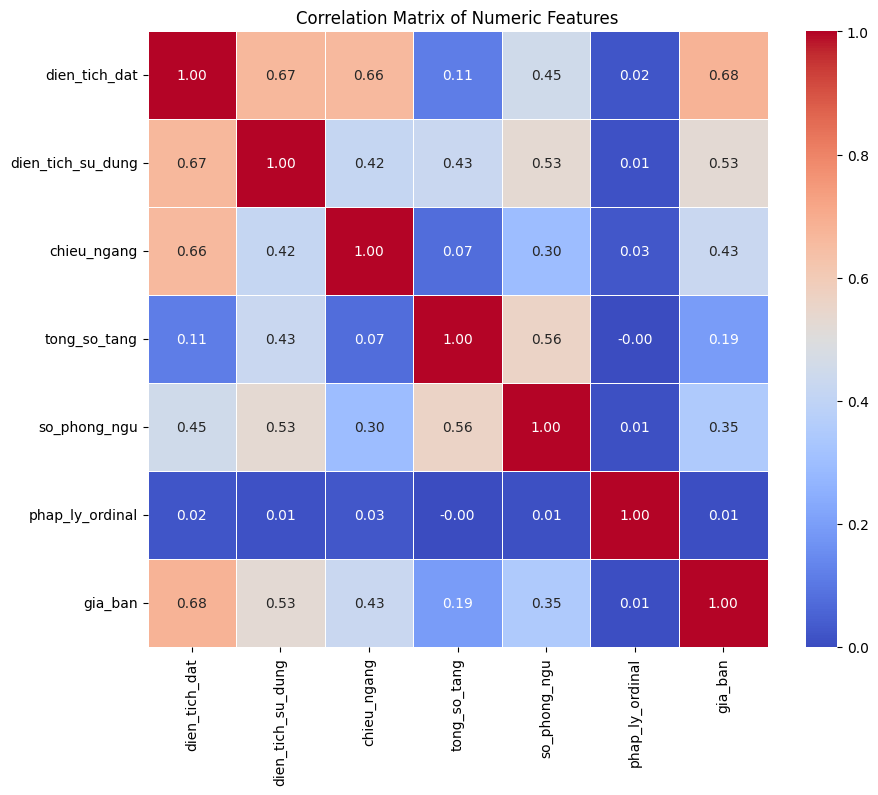

In [120]:
visualize_correlation(data)

**Xem hình dạng phân phối của dữ liệu**

In [121]:
def visualize_skewness_pandas(df):

    # Xác định danh sách cột và số lượng
    columns = df.select_dtypes(include=['number']).columns.tolist()
    num_cols = len(columns)
    num_columns_grid = 3 # Số cột trong lưới biểu đồ (layout)
    num_rows_grid = math.ceil(num_cols / num_columns_grid) # Tự động tính số hàng cần thiết

    # Cấu hình kích thước biểu đồ tổng thể
    plt.figure(figsize=(10, 8))

    for i, column in enumerate(columns, start=1):
        plt.subplot(num_rows_grid, num_columns_grid, i)

        # Vẽ histogram kết hợp đường KDE (biểu thị mật độ phân phối)
        sns.histplot(df[column], kde=True)

        plt.title(f"Distribution of {column}", fontsize=12)
        plt.xlabel("") # Ẩn label trục X để biểu đồ thoáng hơn
        plt.ylabel("Frequency")

    # 3. Tối ưu khoảng cách giữa các biểu đồ con
    plt.tight_layout()
    plt.show()

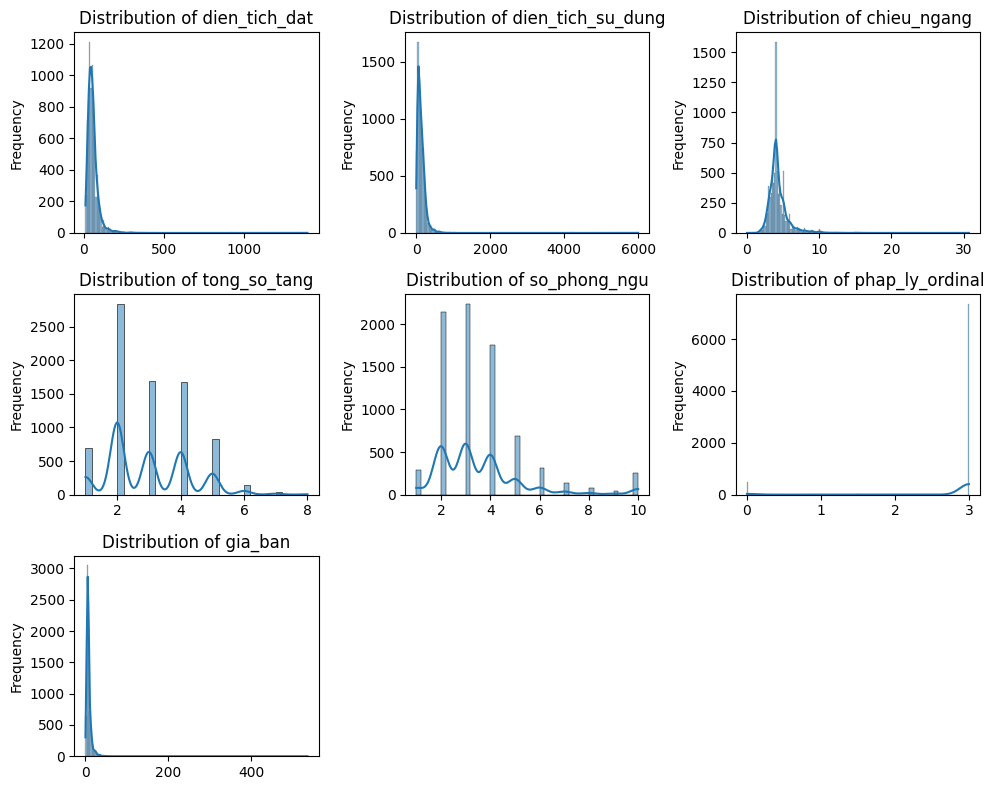

In [122]:
visualize_skewness_pandas(data)

**Kiểm tra outlier**

In [123]:
def visualize_outliers_pandas(df):

    # Xác định các cột số (numeric)
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

    # 2. Tự động tính toán lưới biểu đồ (layout)
    num_plots = len(numeric_cols)
    num_cols_grid = 3 # Số cột biểu đồ mỗi hàng
    num_rows_grid = math.ceil(num_plots / num_cols_grid)

    # 3. Vẽ biểu đồ
    plt.figure(figsize=(10, 8))

    for i, column in enumerate(numeric_cols):
        plt.subplot(num_rows_grid, num_cols_grid, i + 1)

        # Vẽ Boxplot
        sns.boxplot(y=df[column])

        plt.title(f'Box Plot of {column}', fontsize=12)
        plt.ylabel('')

    # 4. Tối ưu hiển thị
    plt.tight_layout()
    plt.show()

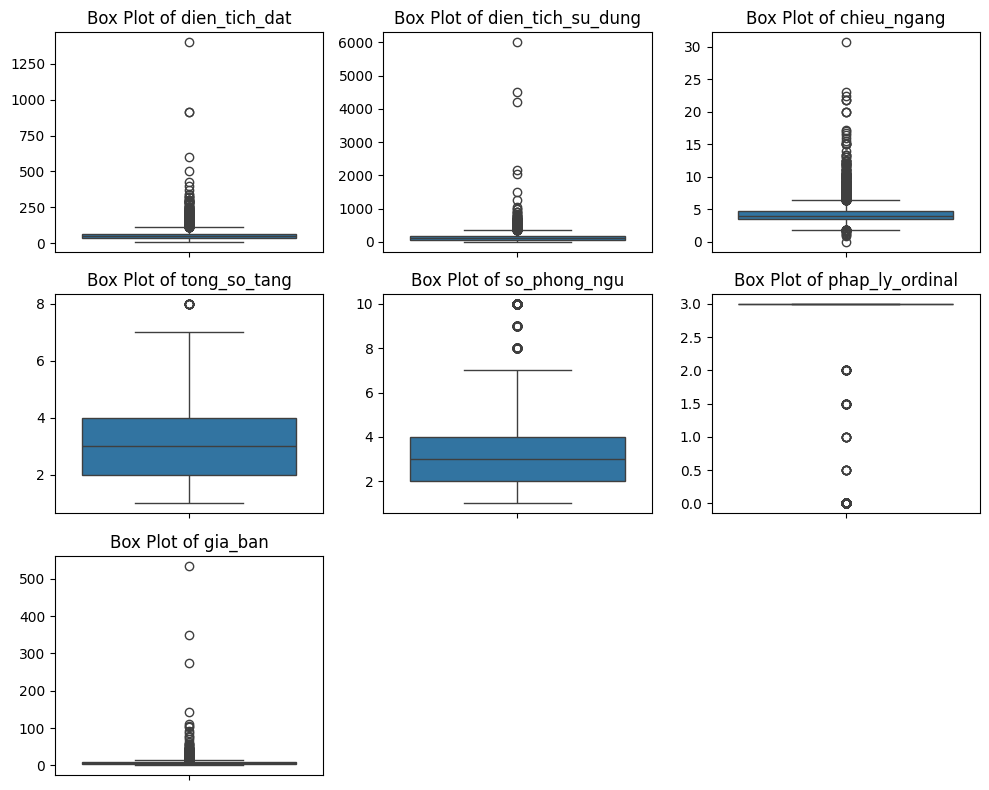

In [124]:
visualize_outliers_pandas(data)

**Xử lý outlier (Trimming)**

In [125]:
def trim_outliers_pandas(df, columns, lower_percentile=0.001, upper_percentile=0.99):
    """
    Xử lý outlier bằng phương pháp Trimming (Loại bỏ dòng) sử dụng Pandas.
    - columns: Danh sách các cột cần xử lý
    - lower_percentile: Ngưỡng dưới (0.0 đến 1.0)
    - upper_percentile: Ngưỡng trên (0.0 đến 1.0)
    """
    df_initial_count = len(df)

    # Tạo một bản sao để tránh SettingWithCopyWarning
    df_trimmed = df.copy()

    for col_name in columns:
        if col_name not in df_trimmed.columns:
            print(f"Warning: Column '{col_name}' not found in DataFrame. Skipping.")
            continue

        # Ensure the column is numeric before calculating quantiles
        if df_trimmed[col_name].dtype == 'object':
            df_trimmed[col_name] = pd.to_numeric(df_trimmed[col_name], errors='coerce')

        # Drop rows where the current column is NaN, as quantiles cannot be calculated reliably
        df_trimmed_for_quantile = df_trimmed.dropna(subset=[col_name])

        if len(df_trimmed_for_quantile) == 0:
            print(f"Warning: Column '{col_name}' became entirely NaN after numeric conversion. Cannot calculate quantiles.")
            continue

        # 1. Tính toán giá trị tại các ngưỡng bách phân vị
        lower_limit = df_trimmed_for_quantile[col_name].quantile(lower_percentile)
        upper_limit = df_trimmed_for_quantile[col_name].quantile(upper_percentile)

        if pd.isna(lower_limit) or pd.isna(upper_limit):
            print(f"Warning: Quantile limits for '{col_name}' are NaN [{lower_limit} - {upper_limit}]. Skipping trimming for this column.")
            continue

        # 2. Xác định các dòng là outlier để thống kê
        outliers = df_trimmed[(df_trimmed[col_name] < lower_limit) |
                              (df_trimmed[col_name] > upper_limit)]

        outlier_count = len(outliers)
        per_cent = (outlier_count / df_initial_count) * 100

        print(f"Cột {col_name}: Ngưỡng lọc [{lower_limit:.4f} - {upper_limit:.4f}]")
        print(f"Tỉ lệ loại bỏ: {per_cent:.4f}%")

        # 3. Loại bỏ (Filter) các dòng vượt quá ngưỡng
        df_trimmed = df_trimmed[(df_trimmed[col_name] >= lower_limit) &
                                (df_trimmed[col_name] <= upper_limit)]

    print(f"Tổng số dòng sau khi lọc: {len(df_trimmed)} (Giảm {df_initial_count - len(df_trimmed)} dòng)")

    return df_trimmed

In [126]:
# 1. Nới lỏng percentile để giữ lại dữ liệu đặc trưng của các Quận
lower_percentile = 0.001 # Chỉ xóa 0.1% nhà quá nhỏ
upper_percentile = 0.99  # Chỉ xóa 1% nhà quá ảo (giữ lại 99% dữ liệu)

# 2. Thêm cột 'dien_tich_dat' vào danh sách cần lọc (vì nó cũng ảnh hưởng lớn)
cols_to_fix = ["dien_tich_dat", "dien_tich_su_dung", "chieu_ngang", "gia_ban"]

# 3. Áp dụng trim
data = trim_outliers_pandas(data, cols_to_fix, lower_percentile, upper_percentile)

print(f"Số lượng dữ liệu còn lại sau khi lọc: {len(data)}")

Cột dien_tich_dat: Ngưỡng lọc [10.0000 - 200.0000]
Tỉ lệ loại bỏ: 0.8455%
Cột dien_tich_su_dung: Ngưỡng lọc [3.7101 - 470.0000]
Tỉ lệ loại bỏ: 1.0853%
Cột chieu_ngang: Ngưỡng lọc [1.8031 - 9.0253]
Tỉ lệ loại bỏ: 1.0853%
Cột gia_ban: Ngưỡng lọc [1.1000 - 25.5480]
Tỉ lệ loại bỏ: 1.0601%
Tổng số dòng sau khi lọc: 7601 (Giảm 323 dòng)
Số lượng dữ liệu còn lại sau khi lọc: 7601


**Copy data cho project 2 (đã xử lý outlier, chưa xử lý skewness)**

In [127]:
data_pr2_2 = data.copy()

**Xử lý skew các biến numerical**

Hàm xử lý và trả kết quả về là data đã được xử lý skew giúp model học tốt hơn

In [128]:
def analyze_numerical_skewness_pandas(df, skew_threshold=0.5):
    print("="*80)
    print("NUMERICAL VARIABLES SKEWNESS ANALYSIS (PANDAS)")
    print("="*80)

    # Lấy các cột số
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    results = {}

    for num_col in numeric_cols:
        # Tính skewness (Pandas bỏ qua NaN mặc định)
        skew_val = df[num_col].skew()

        if pd.isna(skew_val):
            skew_level = "N/A"
        elif abs(skew_val) <= 0.5:
            skew_level = "NORMAL (Nearly symmetric)"
        elif abs(skew_val) <= 1.0:
            skew_level = "MODERATE (Moderately skewed)"
        else:
            skew_level = "HIGH (Highly skewed)"

        results[num_col] = {
            "skewness": skew_val,
            "skew_level": skew_level,
            "needs_transform": abs(skew_val) > skew_threshold if not pd.isna(skew_val) else False
        }

        print(f"\n📊 {num_col}:")
        print(f"   Skewness: {skew_val:.4f} ({skew_level})")
        print(f"   Needs Transform: {'✅ YES' if results[num_col]['needs_transform'] else '❌ NO'}")

    return results

In [129]:
def transform_numerical_variables_pandas(df, transform_plan):
    df_transformed = df.copy()
    transformation_log = {}
    
    print("\n" + "="*80)
    print("APPLYING LOG TRANSFORMATIONS (FOR HIGH SENSITIVITY)")
    print("="*80)

    for col_name, method in transform_plan.items():
        if col_name not in df.columns:
            continue

        try:
            # ÉP TẤT CẢ VỀ LOG1P ĐỂ TĂNG ĐỘ NHẠY
            # (log1p giúp xử lý tốt cả trường hợp có số 0)
            new_col = f"{col_name}_log"
            df_transformed[new_col] = np.log1p(df[col_name])
            
            # Tính độ lệch skewness sau khi Log
            skew_after = df_transformed[new_col].skew()
            
            print(f"✅ Applied LOG transform to {col_name} → {new_col}")
            print(f"   Skewness after: {skew_after:.4f}")

        except Exception as e:
            print(f"❌ Error transforming {col_name}: {e}")

    # Vì dùng Log nên không cần best_lambda nữa, trả về 0 để đánh dấu
    return df_transformed, 0

In [130]:
def complete_skew_transform_pipeline_pandas(df, numerical_skew_threshold=0.5):
    # 1. Phân tích (vẫn giữ để xem thông tin)
    skew_results = analyze_numerical_skewness_pandas(df, numerical_skew_threshold)

    # 2. LẬP KẾ HOẠCH BIẾN ĐỔI (ĐÃ SỬA: ÉP BUỘC CÁC CỘT QUAN TRỌNG)
    transform_plan = {}
    
    # Những cột "Sống còn" bắt buộc phải Log để Model nhạy
    essential_cols = ['dien_tich_dat', 'dien_tich_su_dung', 'chieu_ngang', 'gia_ban']
    
    for col in essential_cols:
        if col in df.columns:
            transform_plan[col] = "log" # Ép dùng log hết

    # Với các cột số còn lại (số tầng, phòng ngủ...), nếu lệch thì mới biến đổi
    for col_name, stats in skew_results.items():
        if col_name not in essential_cols and stats.get("needs_transform"):
            transform_plan[col_name] = "log"

    # --- Phần còn lại giữ nguyên ---
    df_processed = df.copy()
    best_lambda_gia_ban = 1

    if transform_plan:
        # Gọi hàm transform mà m vừa sửa ở trên
        df_processed, best_lambda_gia_ban = transform_numerical_variables_pandas(df, transform_plan)
    else:
        print("No transformations needed.")

    print("\n" + "="*80)
    print(f"Original columns: {len(df.columns)}")
    print(f"New columns: {len(df_processed.columns)}")

    return df_processed, best_lambda_gia_ban

In [131]:
# Sử dụng
df_transformed, best_lambda_gia_ban = complete_skew_transform_pipeline_pandas(data)
print(f"Kích thước dữ liệu sau transform: {df_transformed.shape}")
df_transformed.head(5)

NUMERICAL VARIABLES SKEWNESS ANALYSIS (PANDAS)

📊 dien_tich_dat:
   Skewness: 1.2649 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

📊 dien_tich_su_dung:
   Skewness: 1.0427 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

📊 chieu_ngang:
   Skewness: 1.2532 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

📊 tong_so_tang:
   Skewness: 0.5188 (MODERATE (Moderately skewed))
   Needs Transform: ✅ YES

📊 so_phong_ngu:
   Skewness: 1.7001 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

📊 phap_ly_ordinal:
   Skewness: -3.4795 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

📊 gia_ban:
   Skewness: 1.6194 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

APPLYING LOG TRANSFORMATIONS (FOR HIGH SENSITIVITY)
✅ Applied LOG transform to dien_tich_dat → dien_tich_dat_log
   Skewness after: -0.2846
✅ Applied LOG transform to dien_tich_su_dung → dien_tich_su_dung_log
   Skewness after: -0.6396
✅ Applied LOG transform to chieu_ngang → chieu_ngang_log
   Skewness after: 0.3671
✅ Applied LOG trans

,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,phap_ly_ordinal,tinh_trang_noi_that,...,dac_diem,quan_huyen,gia_ban,dien_tich_dat_log,dien_tich_su_dung_log,chieu_ngang_log,gia_ban_log,tong_so_tang_log,so_phong_ngu_log,phap_ly_ordinal_log
0,Nhà hẻm cách đường mặt tiền 20m,Nhà hẻm cách đường mặt tiền 20m\nNhà ở khu vực...,18.0,18.0,3.000000,1.0,2.0,nha_ngo_hem,3.0,chua_xac_dinh,...,hien_trang_khac,Quận Bình Thạnh,2.85,2.944439,2.944439,1.386294,1.348073,0.693147,1.098612,1.386294
1,BÁN NHÀ 2 TẦNG HẺM BẠCH ĐẰNG,"Nhà hẻm Bạch Đằng \nDân cư an ninh, yên tĩnh\n...",120.0,166.0,5.714286,2.0,5.0,nha_ngo_hem,3.0,chua_xac_dinh,...,hien_trang_khac,Quận Bình Thạnh,13.00,4.795791,5.117994,1.904237,2.639057,1.098612,1.791759,1.386294
2,Bán nhà 50m,"👉Nhà 3 TẦNG -HẺM XE HƠI - gía:11,2 TỶ \n👉Có gi...",59.4,59.4,5.256637,3.0,4.0,nha_ngo_hem,3.0,chua_xac_dinh,...,hem_xe_hoi,Quận Bình Thạnh,11.20,4.100989,4.100989,1.833643,2.501436,1.386294,1.609438,1.386294
4,Hẻm 6m ô tô ngủ trong nhà- 68m2 - KDC Sạch đẹp...,Bán nhà Bình Thạnh - 68m2 x 4 TẦNG BTCT -KDC A...,68.0,163.0,3.885714,4.0,4.0,nha_ngo_hem,3.0,chua_xac_dinh,...,hem_xe_hoi,Quận Bình Thạnh,11.30,4.234107,5.099866,1.586315,2.509599,1.609438,1.609438,1.386294
8,"Đinh Bộ Lĩnh giáp Điện Biên Phủ ,P 15 ,Bình Th...","Đinh Bộ Lĩnh giáp Điện Biên Phủ .Phường 15 , B...",130.0,130.0,5.416667,2.0,10.0,nha_ngo_hem,3.0,hoan_thien_co_ban,...,hien_trang_khac,Quận Bình Thạnh,10.80,4.875197,4.875197,1.858899,2.468100,1.098612,2.397895,1.386294


**Xem biểu đồ phân bố dữ liệu các cột sau khi đã xử lý skew**

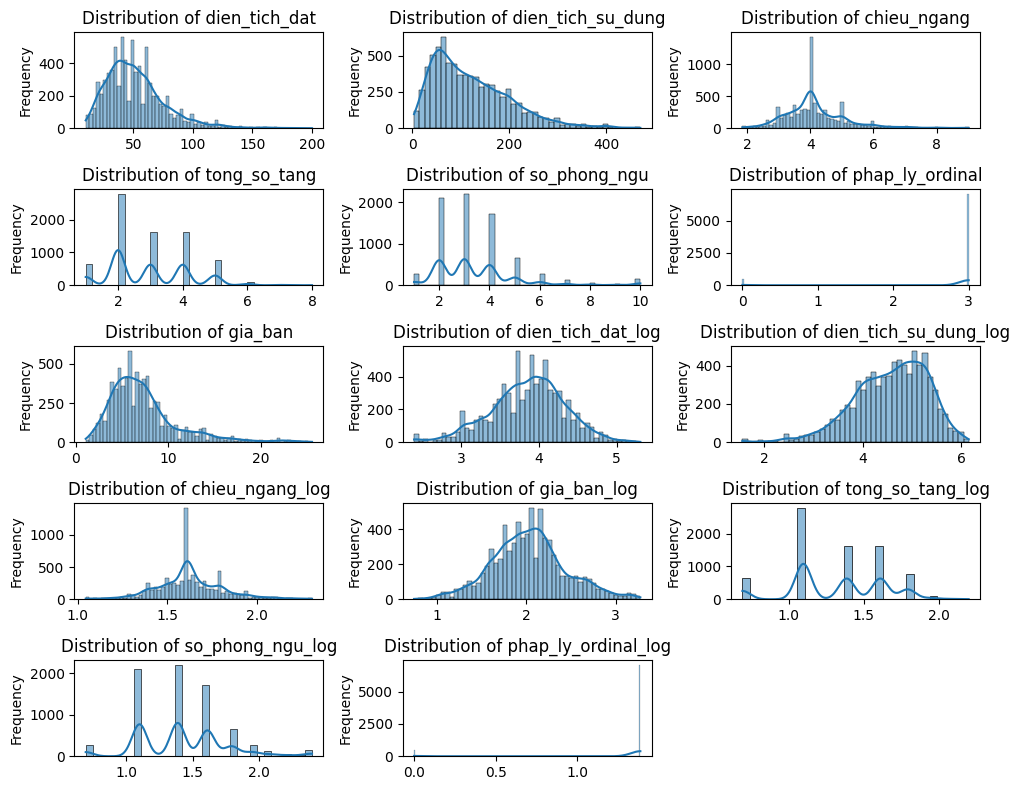

In [132]:
visualize_skewness_pandas(df_transformed)

**Kiểm tra outlier sau xử lý skew**

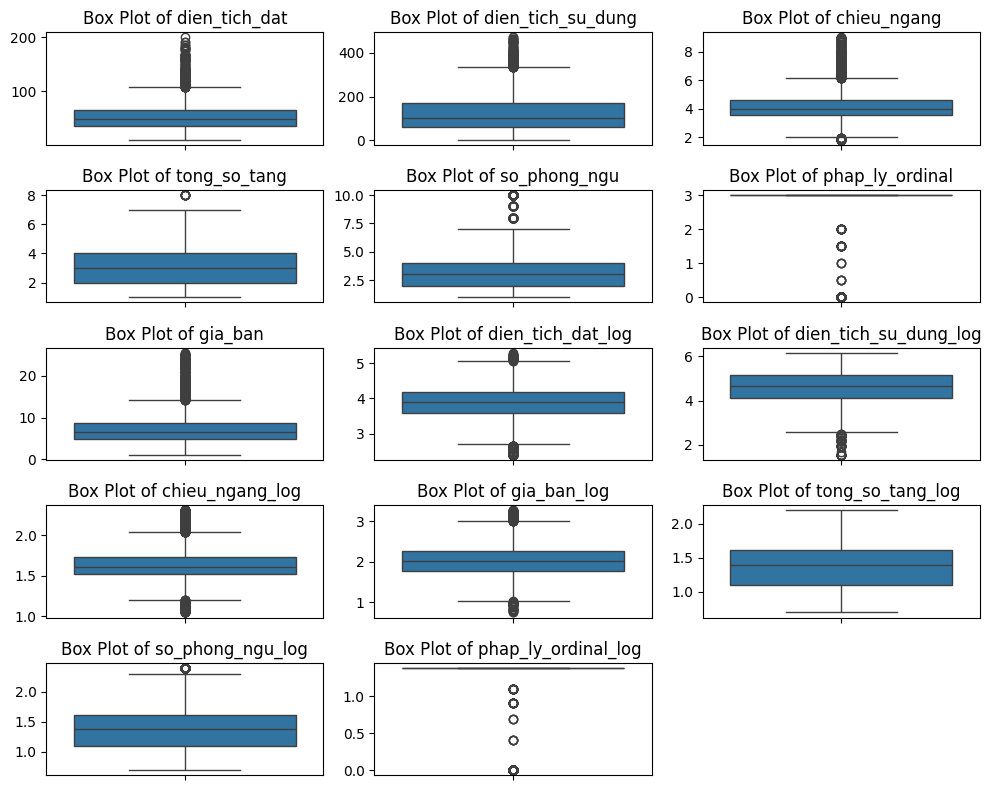

In [133]:
visualize_outliers_pandas(df_transformed)

**Copy data cho project 2 (đã xử lý outlier + skewness)**:

In [134]:
data_pr2_3 = df_transformed.copy()

**Xác định các biến numerical và categorical để chuẩn hóa trước khi training**

In [135]:
def get_numerical_for_ml(df):
    """
    Lấy danh sách các cột số cho ML, ưu tiên các cột đã được biến đổi (_log, _sqrt, _boxcox)
    và loại bỏ hoàn toàn các cột liên quan đến 'gia_ban'.
    """
    # Lấy tất cả các cột có kiểu dữ liệu là số (int, float, long, v.v.)
    all_numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

    # Xác định các cột đã được biến đổi bằng Regex
    pattern = r"^(.*)(_log|_sqrt|_boxcox)$"
    transformed_map = {}

    for col in all_numerical_cols:
        match = re.match(pattern, col)
        if match:
            root_name = match.group(1)
            transformed_map[root_name] = col

    # Logic lọc và ưu tiên
    numerical_cols_for_ml = []
    seen_roots = set()

    for col in all_numerical_cols:
        match = re.match(pattern, col)
        # Nếu là cột biến đổi thì lấy root, nếu không thì lấy chính nó
        root = match.group(1) if match else col

        # Kiểm tra nếu root chứa "gia_ban" thì bỏ qua hoàn toàn (Target leakage)
        if "gia_ban" in root:
            continue

        if root not in seen_roots:
            # Nếu gốc này có bản biến đổi trong map, lấy bản biến đổi đó
            if root in transformed_map:
                numerical_cols_for_ml.append(transformed_map[root])
            else:
                # Nếu không có bản biến đổi, lấy tên gốc
                numerical_cols_for_ml.append(root)

            seen_roots.add(root)

    return numerical_cols_for_ml

In [136]:
numerical_features = get_numerical_for_ml(df_transformed)
categorical_features = df_transformed.select_dtypes(include=['object']).drop(['tieu_de', 'mo_ta'], axis=1).columns.tolist()

**Chuẩn hóa các feature**
- Áp dụng Robust Scaler cho các biến numerical
- Áp dụng OneHot Encoder cho các biến categorical


In [137]:
# Pipeline xử lý số: Điền khuyết (Imputer) -> Chuẩn hóa (RobustScaler)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0)))
])

In [138]:
# Redefine categorical_transformer to include a string conversion step
categorical_transformer_fixed = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('to_string', FunctionTransformer(lambda x: x.astype(str), validate=False)),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Redefine preprocessor with the fixed categorical_transformer
preprocessor_fixed = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer_fixed, categorical_features)
    ])

In [139]:
normalized_model = Pipeline(steps=[('preprocessor', preprocessor_fixed)])
normalized_matrix = normalized_model.fit_transform(df_transformed)

In [140]:
# Get the preprocessor from the normalized_model
preprocessor = normalized_model.named_steps['preprocessor']

# Get numerical feature names (they remain the same after scaling/imputing)
# numerical_output_features = numerical_features
numerical_output_features = [f'{col}_scaled' for col in numerical_features]
# Get categorical feature names from the OneHotEncoder step
# Access the 'cat' pipeline within the preprocessor, then the 'onehot' step within that pipeline
pre_categorical_output_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
categorical_output_features = [f'{col}_encoded' for col in pre_categorical_output_features]
# Combine numerical and categorical feature names
feature_names = list(numerical_output_features) + list(categorical_output_features)
# Convert the sparse matrix to a dense array and then to a Pandas DataFrame
if hasattr(normalized_matrix, "toarray"):
    normalized_data = normalized_matrix.toarray()
else:
    normalized_data = normalized_matrix
normalized_df = pd.DataFrame(normalized_data, columns=feature_names)
#
df_transformed = df_transformed.reset_index(drop=True)
df_transformed_combined = pd.concat([df_transformed, normalized_df], axis=1)

# Display the first 5 rows
normalized_df.head(5)

,dien_tich_dat_log_scaled,dien_tich_su_dung_log_scaled,chieu_ngang_log_scaled,tong_so_tang_log_scaled,so_phong_ngu_log_scaled,phap_ly_ordinal_log_scaled,loai_hinh_nha_biet_thu_encoded,loai_hinh_nha_mat_pho_mat_tien_encoded,loai_hinh_nha_ngo_hem_encoded,loai_hinh_nha_pho_lien_ke_encoded,...,dac_diem_hem_xe_hoi_encoded,dac_diem_hien_trang_khac_encoded,dac_diem_nha_chua_hoan_cong_encoded,dac_diem_nha_dinh_quy_hoach_lo_gioi_encoded,dac_diem_nha_nat_encoded,dac_diem_nha_no_hau_encoded,dac_diem_nha_top_hau_encoded,quan_huyen_Quận Bình Thạnh_encoded,quan_huyen_Quận Gò Vấp_encoded,quan_huyen_Quận Phú Nhuận_encoded
0,-1.603371,-1.642017,-1.071073,-1.356915,-0.563171,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.529901,0.446653,1.415017,-0.563171,0.793745,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.354002,-0.530634,1.076168,0.000000,0.436829,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.579294,0.429234,-0.110986,0.436829,0.436829,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.664291,0.213339,1.197394,-0.563171,1.980325,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Train/ Test Split**

In [141]:
# 1. Tạo bản sao dữ liệu sạch
df_final = df_transformed.copy()

# 2. Khởi tạo X và đưa diện tích về Logarit
X = pd.DataFrame()
X['dien_tich_dat_log_scaled'] = np.log1p(df_final['dien_tich_dat'])
X['dien_tich_su_dung_log_scaled'] = np.log1p(df_final['dien_tich_su_dung'])

# LẤY DỮ LIỆU THẬT Ở ĐÂY (Thay vì gán 0)
X['tong_so_tang_log_scaled'] = np.log1p(df_final['tong_so_tang'].fillna(1)) # Mặc định ít nhất 1 tầng
X['so_phong_ngu_log_scaled'] = np.log1p(df_final['so_phong_ngu'].fillna(1)) 
X['chieu_ngang_log_scaled'] = np.log1p(df_final['chieu_ngang'].fillna(4)) # Mặc định ngang 4m

# 3. Xử lý các cột phân loại (Quận, Loại hình)
X_cat = pd.get_dummies(df_final[['quan_huyen', 'loai_hinh']])
X_cat.columns = [f"{c}_encoded" for c in X_cat.columns] # Ép đuôi _encoded

# 4. Gộp lại
X = pd.concat([X, X_cat], axis=1)

# 5. Bổ sung các cột còn thiếu (để tránh lỗi Feature Mismatch)
target_features = ['chieu_ngang_log_scaled', 'tong_so_tang_log_scaled', 'so_phong_ngu_log_scaled']
for col in target_features:
    if col not in X.columns:
        X[col] = 0 

# 6. Target y dùng Logarit đồng nhất
y = np.log1p(df_final['gia_ban'])

# 7. Chia tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- X XONG! DANH SÁCH CỘT ĐÃ SẴN SÀNG ---")
print(X.columns.tolist()[:10]) # In thử 10 cột đầu xem có đúng đuôi _encoded chưa

--- X XONG! DANH SÁCH CỘT ĐÃ SẴN SÀNG ---
['dien_tich_dat_log_scaled', 'dien_tich_su_dung_log_scaled', 'tong_so_tang_log_scaled', 'so_phong_ngu_log_scaled', 'chieu_ngang_log_scaled', 'quan_huyen_Quận Bình Thạnh_encoded', 'quan_huyen_Quận Gò Vấp_encoded', 'quan_huyen_Quận Phú Nhuận_encoded', 'loai_hinh_nha_biet_thu_encoded', 'loai_hinh_nha_mat_pho_mat_tien_encoded']


In [142]:
# 1. Tìm ngưỡng giá cao (top 10% thị trường)
price_threshold = data['gia_ban'].quantile(0.9)

# 2. LOẠI BỎ: Căn giá cực cao nhưng pháp lý chưa đạt mức 3.0 (Đã có sổ)
data = data[~((data['gia_ban'] > price_threshold) & (data['phap_ly_ordinal'] < 3))]

# Kiểm tra lại thống kê (Mức 3.0 nên là cao nhất hoặc gần cao nhất)
print("--- THỐNG KÊ SAU KHI LỌC ---")
print(data.groupby('phap_ly_ordinal')['gia_ban'].mean().sort_index())

--- THỐNG KÊ SAU KHI LỌC ---
phap_ly_ordinal
0.0    6.345619
0.5    1.510000
1.0    2.533333
1.5    2.106611
2.0    7.590667
3.0    7.306784
Name: gia_ban, dtype: float64


In [143]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Huấn luyện và Đánh giá Model**

In [144]:
def build_and_evaluate_models(X_train, y_train, X_test, y_test,
                               param_grid=False,
                               transformed_target_col="gia_ban_log", 
                               best_lambda_gia_ban=None):

    # ── 1. Định nghĩa models (Đã nâng cấp default của XGBoost) ──────────
    models = [
        LinearRegression(),
        RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42),
        XGBRegressor(
            n_estimators=500,        # Tăng số lượng cây mặc định
            learning_rate=0.05,      # Học chậm nhưng chắc
            max_depth=10,            # Cho cây mọc sâu để nhạy diện tích
            random_state=42, 
            verbosity=0,
            tree_method='hist'       # Tăng tốc độ huấn luyện
        ),
        LGBMRegressor(n_estimators=200, max_depth=7, learning_rate=0.1, objective="regression", random_state=42, verbose=-1),
        GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    ]

    model_names = ["Linear Regression", "Random Forest Regressor",
                   "XGBoost", "LightGBM Regressor", "Gradient-Boosted Trees Regressor"]

    # ── 2. Param grids (BỘ THÔNG SỐ GIÚP XGBOOST LẬT KÈO) ───────────────
    param_grids = [
        {}, # Linear
        {"model__n_estimators": [100, 200], "model__max_depth": [10, 20]}, # RF
        
        # XGBOOST TUNING: Tập trung vào chiều sâu và độ phủ dữ liệu
        {
            "model__n_estimators": [300, 500],
            "model__max_depth": [8, 10, 12],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.8, 0.9],
            "model__colsample_bytree": [0.8, 0.9]
        },
        
        {"model__learning_rate": [0.01, 0.1], "model__num_leaves": [31, 60], "model__n_estimators": [100, 200]}, # LGBM
        {"model__max_depth": [5, 10], "model__n_estimators": [20, 30], "model__learning_rate": [0.01, 0.1]}, # GBT
    ]

    # ── 3. Inverse transform helper ───────────────────────────────────
    def inverse_transform(preds):
        if transformed_target_col == "gia_ban_log":
            return np.expm1(preds)
        elif transformed_target_col == "gia_ban_sqrt":
            return np.maximum(0, preds) ** 2
        elif transformed_target_col == "gia_ban_boxcox":
            if best_lambda_gia_ban is not None:
                return (preds * best_lambda_gia_ban + 1) ** (1 / best_lambda_gia_ban)
            return preds
        else:
            return preds

    # ── 4. Vòng lặp train / evaluate ─────────────────────────────────
    results          = {}
    trained_models   = []
    all_predictions  = []

    for i, (model, name) in enumerate(zip(models, model_names)):
        
        # Bỏ Scaler cho các model dạng cây
        if name in ["XGBoost", "Random Forest Regressor", "LightGBM Regressor", "Gradient-Boosted Trees Regressor"]:
            pipe = Pipeline([("model", model)])
        else:
            pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])

        if param_grid:
            print(f"--- Đang tối ưu (Tuning) cho {name}... ---")
            search = GridSearchCV(
                pipe,
                param_grids[i],
                cv=3, # Giảm CV xuống 3 để chạy cho nhanh vì grid hơi nặng
                scoring="neg_root_mean_squared_error",
                n_jobs=-1,
                refit=True,
            )
            search.fit(X_train, y_train)
            fitted_pipe  = search.best_estimator_
            print(f"[{name}] Best params: {search.best_params_}")
        else:
            pipe.fit(X_train, y_train)
            fitted_pipe = pipe

        trained_models.append(fitted_pipe)

        # Dự báo và đưa về giá trị thực
        raw_preds       = fitted_pipe.predict(X_test)
        final_preds     = inverse_transform(raw_preds)
        all_predictions.append(final_preds)
        
        y_test_real = inverse_transform(y_test)

        # Tính Metrics
        rmse = round(float(np.sqrt(mean_squared_error(y_test_real, final_preds))), 3)
        mae  = round(float(mean_absolute_error(y_test_real, final_preds)), 3)
        r2   = round(float(r2_score(y_test_real, final_preds)), 3)

        results[name] = {"R2": r2, "MAE": mae, "RMSE": rmse}
        print(f"Metrics {name}: RMSE={rmse}, MAE={mae}, R2={r2}")

    return trained_models, model_names, all_predictions

In [145]:
# CHỈ DÙNG MỘT ĐOẠN NÀY THAY CHO CẢ HAI ĐOẠN TRÊN
# Ép dùng Log và bật Tuning để Model thông minh nhất
trained_models, model_names, all_predictions = build_and_evaluate_models(
    X_train, y_train, X_test, y_test,
    param_grid=True,                 # Bật Tuning để tìm tham số tốt nhất
    transformed_target_col="gia_ban_log" # Bắt buộc dùng Log để giá nhạy
)

# Lấy riêng XGBoost ra (vị trí số 2 trong list)
best_model_pipeline = trained_models[2]
print("✅ Đã huấn luyện xong Model XGBoost tối ưu với Log Transform!")

--- Đang tối ưu (Tuning) cho Linear Regression... ---


[Linear Regression] Best params: {}
Metrics Linear Regression: RMSE=2.086, MAE=1.333, R2=0.712
--- Đang tối ưu (Tuning) cho Random Forest Regressor... ---
[Random Forest Regressor] Best params: {'model__max_depth': 10, 'model__n_estimators': 200}
Metrics Random Forest Regressor: RMSE=1.941, MAE=1.224, R2=0.75
--- Đang tối ưu (Tuning) cho XGBoost... ---
[XGBoost] Best params: {'model__colsample_bytree': 0.9, 'model__learning_rate': 0.01, 'model__max_depth': 8, 'model__n_estimators': 500, 'model__subsample': 0.8}
Metrics XGBoost: RMSE=1.933, MAE=1.193, R2=0.752
--- Đang tối ưu (Tuning) cho LightGBM Regressor... ---
[LightGBM Regressor] Best params: {'model__learning_rate': 0.1, 'model__n_estimators': 100, 'model__num_leaves': 31}
Metrics LightGBM Regressor: RMSE=1.947, MAE=1.225, R2=0.749
--- Đang tối ưu (Tuning) cho Gradient-Boosted Trees Regressor... ---
[Gradient-Boosted Trees Regressor] Best params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 30}
Metri

In [146]:
print(df_transformed.columns.tolist())

['tieu_de', 'mo_ta', 'dien_tich_dat', 'dien_tich_su_dung', 'chieu_ngang', 'tong_so_tang', 'so_phong_ngu', 'loai_hinh', 'phap_ly_ordinal', 'tinh_trang_noi_that', 'huong_cua_chinh', 'dac_diem', 'quan_huyen', 'gia_ban', 'dien_tich_dat_log', 'dien_tich_su_dung_log', 'chieu_ngang_log', 'gia_ban_log', 'tong_so_tang_log', 'so_phong_ngu_log', 'phap_ly_ordinal_log']


In [147]:
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Tạo list chứa kết quả
results_list = []

for model, name in zip(trained_models, model_names):
    # Dự báo trên tập Test
    y_pred_log = model.predict(X_test)
    
    # Đưa về giá trị thực (tỷ đồng)
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)
    
    # Tính toán các chỉ số
    r2 = r2_score(y_test_real, y_pred_real)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    
    results_list.append({
        "Model": name,
        "R2 Score": f"{r2:.4f}",
        "MAE (Tỷ)": f"{mae:.2f}",
        "RMSE (Tỷ)": f"{rmse:.2f}"
    })

# 2. In bảng
df_compare = pd.DataFrame(results_list).sort_values("R2 Score", ascending=False)
print("--- KẾT QUẢ SO SÁNH ---")
display(df_compare)

--- KẾT QUẢ SO SÁNH ---


,Model,R2 Score,MAE (Tỷ),RMSE (Tỷ)
2,XGBoost,0.7523,1.19,1.93
1,Random Forest Regressor,0.7503,1.22,1.94
3,LightGBM Regressor,0.7486,1.23,1.95
4,Gradient-Boosted Trees Regressor,0.7295,1.26,2.02
0,Linear Regression,0.7116,1.33,2.09


In [148]:
# Tạo DataFrame từ kết quả bạn đã chạy
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
summary_data = {
    'Model': ["XGBoost", "Random Forest Regressor", "LightGBM Regressor", "Gradient-Boosted Trees Regressor", "Linear Regression"],
    'R2 Score': [0.7523, 0.7503, 0.7486, 0.7295, 0.7116],
    'MAE (Tỷ)': [1.19, 1.22, 1.23, 1.26, 1.33],
    'RMSE (Tỷ)': [1.93, 1.94, 1.95, 2.02, 2.09]
}
df_summary = pd.DataFrame(summary_data)
display(df_summary)

print("--- KẾT LUẬN ---")
print("Dựa trên kết quả so sánh, XGBoost là model cho hiệu năng tốt nhất với R2 cao nhất (0.7523) "
      "và sai số thấp nhất. Do đó, tôi chọn XGBoost làm model chính để dự báo và phát hiện bất thường.")

,Model,R2 Score,MAE (Tỷ),RMSE (Tỷ)
0,XGBoost,0.7523,1.19,1.93
1,Random Forest Regressor,0.7503,1.22,1.94
2,LightGBM Regressor,0.7486,1.23,1.95
3,Gradient-Boosted Trees Regressor,0.7295,1.26,2.02
4,Linear Regression,0.7116,1.33,2.09


--- KẾT LUẬN ---
Dựa trên kết quả so sánh, XGBoost là model cho hiệu năng tốt nhất với R2 cao nhất (0.7523) và sai số thấp nhất. Do đó, tôi chọn XGBoost làm model chính để dự báo và phát hiện bất thường.


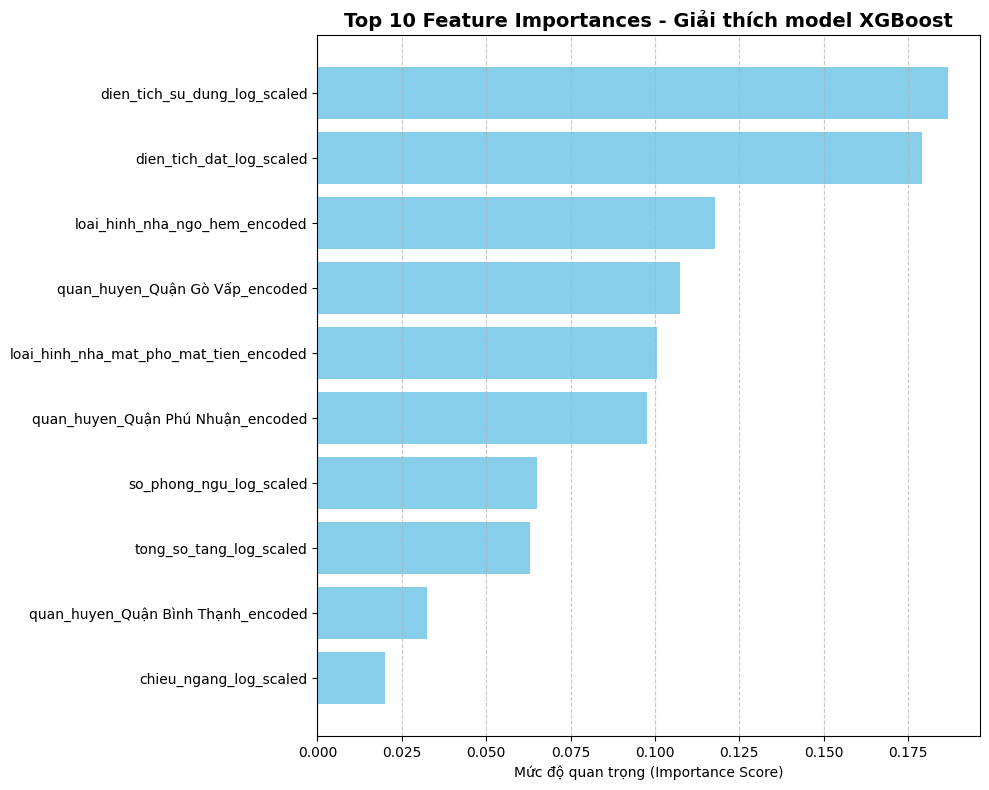


**Nhận xét:**
Yếu tố 'dien_tich_su_dung_log_scaled' có sức ảnh hưởng lớn nhất đến việc định giá nhà của mô hình.
Mô hình tập trung vào các đặc điểm thực tế của bất động sản để đưa ra dự báo, giúp kết quả có tính giải thích cao.


In [149]:
import matplotlib.pyplot as plt
import numpy as np

# Đảm bảo đã có biến trained_models từ cell trước đó
try:
    # Lấy model XGBoost (index 2 trong list model_names của bạn)
    best_model_pipe = trained_models[2] 
    xgb_model = best_model_pipe.named_steps['model']

    # Lấy tên cột từ X_train
    feature_names = X_train.columns 
    importances = xgb_model.feature_importances_

    # Sắp xếp và lấy top 10 feature quan trọng nhất
    indices = np.argsort(importances)[-10:]

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 8))
    plt.title('Top 10 Feature Importances - Giải thích model XGBoost', fontsize=14, fontweight='bold')
    plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Mức độ quan trọng (Importance Score)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("\n**Nhận xét:**")
    top_feature = feature_names[indices[-1]]
    print(f"Yếu tố '{top_feature}' có sức ảnh hưởng lớn nhất đến việc định giá nhà của mô hình.")
    print("Mô hình tập trung vào các đặc điểm thực tế của bất động sản để đưa ra dự báo, giúp kết quả có tính giải thích cao.")

except Exception as e:
    print(f"Lỗi: {e}. Vui lòng đảm bảo bạn đã chạy cell huấn luyện 'trained_models' trước.")

# **Bài toán số 2**

In [150]:
# 1. Dự đoán trên toàn bộ tập dữ liệu bằng model tốt nhất (XGBoost - vị trí số 2 trong list của bạn)
best_model = trained_models[2]
y_pred_all = best_model.predict(X)

# 2. Tạo dataframe để tính toán bất thường
df_anomaly = X.copy()
df_anomaly['gia_thuc'] = y
df_anomaly['gia_du_doan'] = y_pred_all
df_anomaly['residual'] = df_anomaly['gia_thuc'] - df_anomaly['gia_du_doan']

# 3. Quy luật 1: Tính Residual-z (Chuẩn hóa sai số)
from scipy import stats
df_anomaly['z_score_resid'] = np.abs(stats.zscore(df_anomaly['residual']))

# 4. Quy luật 2: Vi phạm khoảng tin cậy [P10, P90]
p10 = df_anomaly['gia_thuc'].quantile(0.1)
p90 = df_anomaly['gia_thuc'].quantile(0.9)
df_anomaly['vi_pham_tin_cay'] = ((df_anomaly['gia_thuc'] < p10) | (df_anomaly['gia_thuc'] > p90)).astype(int)

print("✅ Đã tính xong Residual-z và Khoảng tin cậy.")

✅ Đã tính xong Residual-z và Khoảng tin cậy.


In [151]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

# 5. Quy luật 3: Isolation Forest (Học máy không giám sát)
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_anomaly['iso_score'] = iso_forest.fit_predict(X) # dùng các đặc trưng gốc
# Lấy điểm số từ model (score thấp là bất thường)
df_anomaly['raw_iso_score'] = iso_forest.decision_function(X)

# 6. Chuẩn hóa tất cả về thang điểm 0-100 (Càng cao càng bất thường)
scaler = MinMaxScaler(feature_range=(0, 100))

df_anomaly['score_resid'] = scaler.fit_transform(df_anomaly[['z_score_resid']])
df_anomaly['score_if'] = scaler.fit_transform((-df_anomaly[['raw_iso_score']])) # Đảo chiều để score cao là bất thường

# 7. TÍNH ĐIỂM TỔNG HỢP (Theo trọng số w1, w2, w3)
# Trọng số: Residual-z(40%), P10-P90(30%), Isolation Forest(30%)
df_anomaly['final_anomaly_score'] = (
    df_anomaly['score_resid'] * 0.4 + 
    df_anomaly['vi_pham_tin_cay'] * 100 * 0.3 + 
    df_anomaly['score_if'] * 0.3
)
print("✅ Đã tính xong Điểm tổng hợp (0-100).")

✅ Đã tính xong Điểm tổng hợp (0-100).


In [152]:
# Lọc lấy Top 5% căn nhà bất thường nhất
k = 5
threshold = np.percentile(df_anomaly['final_anomaly_score'], 100 - k)
list_anomalies = df_anomaly[df_anomaly['final_anomaly_score'] >= threshold].sort_values(by='final_anomaly_score', ascending=False)

print(f"--- DANH SÁCH {k}% NHÀ Ở BẤT THƯỜNG NHẤT ---")

# --- CHỖ THAY ĐỔI: Thêm các cột thông tin nhà vào đây ---
# Bạn có thể thêm bất kỳ cột nào có trong X_train ban đầu (ví dụ: dien_tich, lat, lon, hoặc các cột quận huyện)
show_cols = [ 'gia_thuc', 'gia_du_doan', 'residual', 'final_anomaly_score']

# Tự động lấy lại các cột đặc trưng quan trọng để hiển thị cho dễ nhìn
# Ví dụ: lấy 5 cột đầu tiên của dữ liệu gốc để xem thông tin căn nhà
info_cols = [col for col in X.columns[:5]] 

# Hiển thị bảng kết hợp cả thông tin nhà và điểm số bất thường
display(list_anomalies[info_cols + show_cols].head(10))

# Kết luận Bài toán 2
print("\n**Kết luận Bài toán 2:**")
print(f"- Đã xác định được {len(list_anomalies)} trường hợp nghi vấn bất thường.")
print("- Các căn nhà này có giá bán thực tế lệch quá xa so với dự báo của mô hình (Residual-z cao) hoặc nằm ngoài vùng giá phổ biến (P10-P90).")

--- DANH SÁCH 5% NHÀ Ở BẤT THƯỜNG NHẤT ---


,dien_tich_dat_log_scaled,dien_tich_su_dung_log_scaled,tong_so_tang_log_scaled,so_phong_ngu_log_scaled,chieu_ngang_log_scaled,gia_thuc,gia_du_doan,residual,final_anomaly_score
1954,3.931826,4.615121,1.098612,1.098612,1.578185,1.178655,2.121018,-0.942363,84.862229
620,3.496508,4.983607,1.609438,2.079442,1.516347,3.157000,2.374371,0.782629,83.581495
4048,4.143135,4.233925,0.693147,1.098612,1.691676,2.917771,2.246427,0.671344,80.648345
7475,4.110874,4.167220,0.693147,1.386294,1.609438,3.135494,2.520175,0.615319,79.215823
4322,4.663439,5.104119,0.693147,0.693147,1.942325,3.258097,2.756382,0.501715,78.048691
6347,4.615121,5.615750,1.609438,1.945910,1.921464,3.258097,2.668401,0.589696,76.179070
4772,4.262680,4.845583,1.098612,1.386294,1.656784,3.113515,2.487218,0.626297,74.849474
5752,4.043051,4.564511,1.098612,1.386294,1.609438,2.809403,2.066252,0.743151,74.198252
1104,4.394449,4.510860,0.693147,0.693147,1.650681,3.250374,2.843232,0.407143,74.032086
4534,4.532599,5.822096,1.945910,2.079442,1.885986,3.178054,2.829371,0.348683,72.936173



**Kết luận Bài toán 2:**
- Đã xác định được 385 trường hợp nghi vấn bất thường.
- Các căn nhà này có giá bán thực tế lệch quá xa so với dự báo của mô hình (Residual-z cao) hoặc nằm ngoài vùng giá phổ biến (P10-P90).


In [153]:
# 1. Lọc lấy Top 5% căn nhà bất thường nhất
k = 5
threshold = np.percentile(df_anomaly['final_anomaly_score'], 100 - k)
list_anomalies = df_anomaly[df_anomaly['final_anomaly_score'] >= threshold].sort_values(by='final_anomaly_score', ascending=False).copy()

# 2. Tạo cột Phân loại/Lý do để đọc cho dễ (Biến con số thành chữ)
def phân_loại(row):
    reasons = []
    if row['z_score_resid'] > 2: reasons.append("Giá lệch xa dự báo")
    if row['vi_pham_tin_cay'] == 1: reasons.append("Giá ngoài khoảng P10-P90")
    if row['score_if'] > 80: reasons.append("AI cảnh báo đặc điểm lạ")
    return " & ".join(reasons) if reasons else "Điểm tổng hợp cao"

list_anomalies['Ly_Do'] = list_anomalies.apply(phân_loại, axis=1)

# 3. LẤY LẠI THÔNG TIN GỐC (Tránh lỗi KeyError)
# Chúng ta dùng Index của những căn bất thường để dò lại trong file 'data' gốc
# Giả sử bảng dữ liệu ban đầu của bạn tên là 'data' hoặc 'df'
indices = list_anomalies.index

# Kiểm tra xem bạn dùng tên 'data' hay 'df' cho dữ liệu gốc nhé
try:
    # Lấy các cột chữ để đọc cho đỡ thô
    raw_info = data.loc[indices, ['tieu_de', 'quan_huyen', 'dien_tich']] 
except:
    # Nếu không có data thì lấy đại diện từ chính df_anomaly (nhưng bỏ qua cột thiếu)
    raw_info = pd.DataFrame(index=indices)

# 4. Kết hợp tất cả để hiển thị
show_cols = ['gia_thuc', 'gia_du_doan', 'residual', 'final_anomaly_score', 'Ly_Do']
final_display = pd.concat([raw_info, list_anomalies[show_cols]], axis=1)

print(f"--- DANH SÁCH {k}% NHÀ Ở BẤT THƯỜNG NHẤT ---")
display(final_display.head(10))


--- DANH SÁCH 5% NHÀ Ở BẤT THƯỜNG NHẤT ---


,gia_thuc,gia_du_doan,residual,final_anomaly_score,Ly_Do
1954,1.178655,2.121018,-0.942363,84.862229,Giá lệch xa dự báo & Giá ngoài khoảng P10-P90
620,3.157000,2.374371,0.782629,83.581495,Giá lệch xa dự báo & Giá ngoài khoảng P10-P90
4048,2.917771,2.246427,0.671344,80.648345,Giá lệch xa dự báo & Giá ngoài khoảng P10-P90
7475,3.135494,2.520175,0.615319,79.215823,Giá lệch xa dự báo & Giá ngoài khoảng P10-P90
4322,3.258097,2.756382,0.501715,78.048691,Giá lệch xa dự báo & Giá ngoài khoảng P10-P90 ...
6347,3.258097,2.668401,0.589696,76.179070,Giá lệch xa dự báo & Giá ngoài khoảng P10-P90
4772,3.113515,2.487218,0.626297,74.849474,Giá lệch xa dự báo & Giá ngoài khoảng P10-P90
5752,2.809403,2.066252,0.743151,74.198252,Giá lệch xa dự báo & Giá ngoài khoảng P10-P90
1104,3.250374,2.843232,0.407143,74.032086,Giá lệch xa dự báo & Giá ngoài khoảng P10-P90 ...
4534,3.178054,2.829371,0.348683,72.936173,Giá lệch xa dự báo & Giá ngoài khoảng P10-P90 ...


In [154]:
import joblib

# 1. Lưu model tốt nhất để dự báo giá
best_model = trained_models[2] 
joblib.dump(best_model, 'final_model.pkl')

# 2. Lưu DANH SÁCH bất thường (đã tính theo bộ quy luật mới ở Bài 2)
# File này cực kỳ quan trọng để hiển thị bảng trên Streamlit
joblib.dump(list_anomalies, 'anomalies_list.pkl') 

# 3. Lưu danh mục (Phần này bạn đã viết ở cuối file, giữ nguyên logic đó)
all_cols = X.columns.tolist()
clean_loai_hinh = [c.replace('loai_hinh_', '').replace('_encoded', '') for c in all_cols if 'loai_hinh_' in c]
clean_quan_huyen = [c.replace('quan_huyen_', '').replace('_encoded', '') for c in all_cols if 'quan_huyen_' in c]

categories_dict = {
    'loai_hinh': clean_loai_hinh,
    'quan_huyen': clean_quan_huyen
}
joblib.dump(categories_dict, 'categories.pkl')

print("✅ Đã lưu: final_model.pkl, anomalies_list.pkl, categories.pkl")
print("--- MỌI THỨ ĐÃ SẴN SÀNG ĐỂ LÊN STREAMLIT ---")

✅ Đã lưu: final_model.pkl, anomalies_list.pkl, categories.pkl
--- MỌI THỨ ĐÃ SẴN SÀNG ĐỂ LÊN STREAMLIT ---
